In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%pip install torchinfo

In [ ]:
# =====================
# Standard Libraries
# =====================
import os
import time
import random
import glob
import platform
from collections import OrderedDict, Counter, defaultdict
import shutil

# # =====================
# # Data Handling
# # =====================
import numpy as np
import pandas as pd
from tabulate import tabulate

# # =====================
# # Visualization
# # =====================
import matplotlib.pyplot as plt
import seaborn as sns

# # =====================
# # Image Processing
# # =====================
import cv2
from PIL import Image, ImageOps
from torchvision import transforms
from torchvision.transforms import (
     ColorJitter, RandomRotation, RandomResizedCrop
 )
from torchvision.transforms.functional import gaussian_blur

# # =====================
# # Machine Learning
# #====================
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
 )

# # =====================
# # PyTorch Core
# # =====================
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

# # =====================
# # PyTorch Models & Training
# # =====================
import torchvision
import torchvision.models as models
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
# Install torchinfo if not already installed
try:
    from torchinfo import summary
except ImportError:
    !pip install torchinfo
    from torchinfo import summary


# # =====================
# # Augmentation (Albumentations)
# # =====================
from albumentations import Compose, Rotate, HorizontalFlip

# # =====================
# # Progress Monitoring
# # =====================
from tqdm import tqdm, notebook as tqdm_notebook
import psutil

Imported all the libraries

In [ ]:
# Define dataset paths
data_dir = '/content/drive/MyDrive/ml project/aug'

Defining datapath to use the data

Class Counts:
                  class  count
0          Prorocentrum    168
1   Thalassiosira_dirty    190
2       Pseudonitzschia    578
3     other_interaction    211
4               pennate    330
5           Skeletonema    342
6           Pleurosigma    100
7     Guinardia_striata    447
8        flagellate_sp3    177
9         Mesodinium_sp    107
10              Ditylum    217
11            Dinobryon    588
12        Dactyliosolen    532
13     DactFragCerataul    175
14            Corethron    447
15          Cerataulina    412
16     Asterionellopsis    128


/tmp/ipython-input-4072860896.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='class', y='count', palette='viridis')


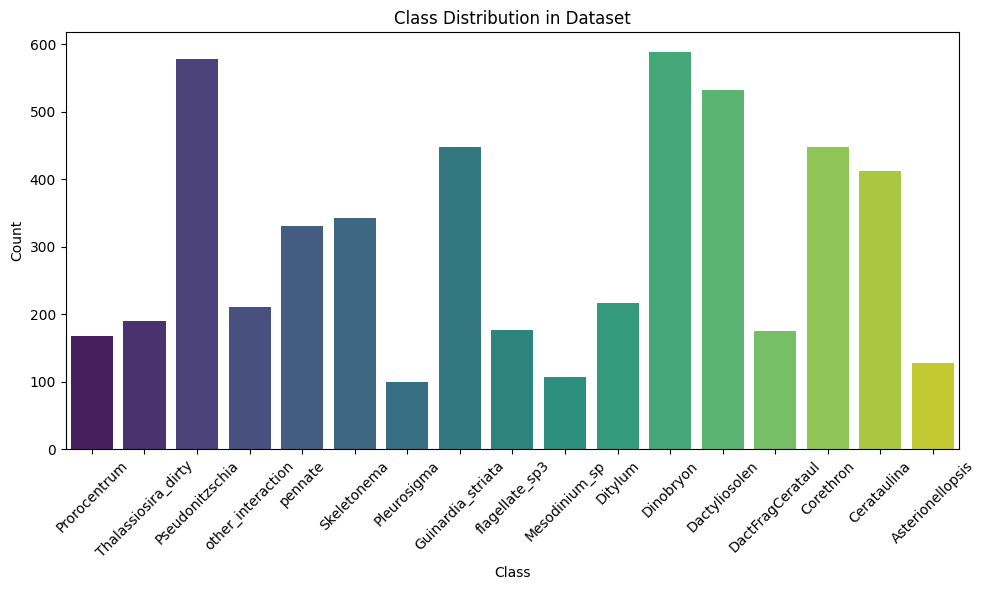

In [ ]:
# Path to your dataset
dataset_path = '/content/drive/MyDrive/ml project/aug'
# Get class counts
class_counts = {}
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_path):  # Ensure it's a directory
        class_counts[class_name] = len(os.listdir(class_path))

# Convert to DataFrame for visualization
df = pd.DataFrame.from_dict(class_counts, orient='index', columns=['count'])
df = df.reset_index().rename(columns={'index': 'class'})

# Print class counts
print("Class Counts:")
print(df)

# Create a count plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='class', y='count', palette='viridis')
plt.title('Class Distribution in Dataset')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

Visualizing the dataset's class count. From the plot we can see that, the dataset is highly imbalanced and only selected classes needs to be augmented. thus we will augment these classes in the next step so that we could make our own customized dataset.

In [ ]:


# Get class counts
class_counts = {}
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_path):  # Ensure it's a directory
        class_counts[class_name] = len(os.listdir(class_path))

# Convert to DataFrame for easier manipulation
df = pd.DataFrame.from_dict(class_counts, orient='index', columns=['count'])
df = df.reset_index().rename(columns={'index': 'class'})

# Calculate total samples and number of classes
total_samples = df['count'].sum()
num_classes = len(df)

# Calculate percentage per class
df['percentage'] = (df['count'] / total_samples * 100).round(2)

# Identify most and least frequent classes
most_frequent = df.loc[df['count'].idxmax()]
least_frequent = df.loc[df['count'].idxmin()]

# Generate textual summary
print("=== Dataset Class Distribution Summary ===")
print(f"Dataset Path: {dataset_path}")
print(f"Total Number of Samples: {total_samples}")
print(f"Number of Classes: {num_classes}")
print("\nClass Counts and Percentages:")
for _, row in df.iterrows():
    print(f"Class: {row['class']}, Count: {row['count']}, Percentage: {row['percentage']}%")
print(f"\nMost Frequent Class: {most_frequent['class']} ({most_frequent['count']} samples, {most_frequent['percentage']}%)")
print(f"Least Frequent Class: {least_frequent['class']} ({least_frequent['count']} samples, {least_frequent['percentage']}%)")
print(f"Class Imbalance Ratio (Max/Min): {(most_frequent['count'] / least_frequent['count']):.2f}")
print("========================================")



=== Dataset Class Distribution Summary ===
Dataset Path: /content/drive/MyDrive/ml project/aug
Total Number of Samples: 5149
Number of Classes: 17

Class Counts and Percentages:
Class: Prorocentrum, Count: 168, Percentage: 3.26%
Class: Thalassiosira_dirty, Count: 190, Percentage: 3.69%
Class: Pseudonitzschia, Count: 578, Percentage: 11.23%
Class: other_interaction, Count: 211, Percentage: 4.1%
Class: pennate, Count: 330, Percentage: 6.41%
Class: Skeletonema, Count: 342, Percentage: 6.64%
Class: Pleurosigma, Count: 100, Percentage: 1.94%
Class: Guinardia_striata, Count: 447, Percentage: 8.68%
Class: flagellate_sp3, Count: 177, Percentage: 3.44%
Class: Mesodinium_sp, Count: 107, Percentage: 2.08%
Class: Ditylum, Count: 217, Percentage: 4.21%
Class: Dinobryon, Count: 588, Percentage: 11.42%
Class: Dactyliosolen, Count: 532, Percentage: 10.33%
Class: DactFragCerataul, Count: 175, Percentage: 3.4%
Class: Corethron, Count: 447, Percentage: 8.68%
Class: Cerataulina, Count: 412, Percentage: 8.

Checking the textual summary of the dataset.

In [ ]:
from google.colab import drive
import os
import random
import shutil
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Mount Google Drive
drive.mount('/content/drive')

# Define paths
original_path = '/content/drive/MyDrive/ml project/aug'
balanced_path = os.path.join(original_path, 'balanced')

# Create balanced directory if it doesn't exist
os.makedirs(balanced_path, exist_ok=True)

# List of classes (from your summary)
classes = [
    'Prorocentrum', 'Thalassiosira_dirty', 'Pseudonitzschia', 'other_interaction',
    'pennate', 'Skeletonema', 'Pleurosigma', 'Guinardia_striata', 'flagellate_sp3',
    'Mesodinium_sp', 'Ditylum', 'Dinobryon', 'Dactyliosolen', 'DactFragCerataul',
    'Corethron', 'Cerataulina', 'Asterionellopsis'
]

# Class counts from your summary (hardcoded for accuracy)
class_counts = {
    'Prorocentrum': 168,
    'Thalassiosira_dirty': 190,
    'Pseudonitzschia': 578,
    'other_interaction': 211,
    'pennate': 330,
    'Skeletonema': 342,
    'Pleurosigma': 100,
    'Guinardia_striata': 447,
    'flagellate_sp3': 177,
    'Mesodinium_sp': 107,
    'Ditylum': 217,
    'Dinobryon': 588,
    'Dactyliosolen': 532,
    'DactFragCerataul': 175,
    'Corethron': 447,
    'Cerataulina': 412,
    'Asterionellopsis': 128
}

# Target count per class
target_count = 600

# ImageDataGenerator for augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Process each class
for class_name in classes:
    orig_class_dir = os.path.join(original_path, class_name)
    new_class_dir = os.path.join(balanced_path, class_name)
    os.makedirs(new_class_dir, exist_ok=True)

    # Get list of original images
    images = [f for f in os.listdir(orig_class_dir) if os.path.isfile(os.path.join(orig_class_dir, f))]
    num_orig = class_counts[class_name]  # Use provided count for accuracy

    if num_orig > target_count:
        # Downsample if more than target (though not needed based on counts)
        selected_images = random.sample(images, target_count)
        for img_name in selected_images:
            src = os.path.join(orig_class_dir, img_name)
            dst = os.path.join(new_class_dir, img_name)
            shutil.copy(src, dst)
        print(f"Class {class_name}: Downsampled from {num_orig} to {target_count}")
    else:
        # Copy all original images
        for img_name in images:
            src = os.path.join(orig_class_dir, img_name)
            dst = os.path.join(new_class_dir, img_name)
            shutil.copy(src, dst)

        # Augment if needed
        num_to_aug = target_count - num_orig
        if num_to_aug > 0:
            aug_count = 0
            while aug_count < num_to_aug:
                # Randomly select an original image
                img_name = random.choice(images)
                img_path = os.path.join(orig_class_dir, img_name)
                img = load_img(img_path)
                x = img_to_array(img)
                x = x.reshape((1,) + x.shape)

                # Generate one augmented image
                for batch in datagen.flow(
                    x,
                    batch_size=1,
                    save_to_dir=new_class_dir,
                    save_prefix=f'aug_{class_name}_',
                    save_format='jpg'  # Assuming JPG; change to 'png' if needed
                ):
                    aug_count += 1
                    break  # Only generate one per iteration

                if aug_count % 50 == 0:
                    print(f"Class {class_name}: Generated {aug_count}/{num_to_aug} augmented images")

            print(f"Class {class_name}: Augmented from {num_orig} to {target_count}")
        else:
            print(f"Class {class_name}: Already at or above {target_count}, no augmentation needed")

print("Balancing complete. Balanced dataset is at:", balanced_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Class Prorocentrum: Generated 50/432 augmented images
Class Prorocentrum: Generated 100/432 augmented images
Class Prorocentrum: Generated 150/432 augmented images
Class Prorocentrum: Generated 200/432 augmented images
Class Prorocentrum: Generated 250/432 augmented images
Class Prorocentrum: Generated 300/432 augmented images
Class Prorocentrum: Generated 350/432 augmented images
Class Prorocentrum: Generated 400/432 augmented images
Class Prorocentrum: Augmented from 168 to 600
Class Thalassiosira_dirty: Generated 50/410 augmented images
Class Thalassiosira_dirty: Generated 100/410 augmented images
Class Thalassiosira_dirty: Generated 150/410 augmented images
Class Thalassiosira_dirty: Generated 200/410 augmented images
Class Thalassiosira_dirty: Generated 250/410 augmented images
Class Thalassiosira_dirty: Generated 300/410 augmented images
Class Thalassio

Augmented the images so that we could make a balanced dataset. Here we have augmented so that each class may contain 600 images.

In [ ]:
import os
import pandas as pd

# Path to the balanced dataset
balanced_path = '/content/drive/MyDrive/ml project/aug/balanced'

# Get class counts
class_counts = {}
for class_name in os.listdir(balanced_path):
    class_path = os.path.join(balanced_path, class_name)
    if os.path.isdir(class_path):  # Ensure it's a directory
        class_counts[class_name] = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])

# Convert to DataFrame for easier manipulation
df = pd.DataFrame.from_dict(class_counts, orient='index', columns=['count'])
df = df.reset_index().rename(columns={'index': 'class'})

# Calculate total samples and number of classes
total_samples = df['count'].sum()
num_classes = len(df)

# Calculate percentage per class
df['percentage'] = (df['count'] / total_samples * 100).round(2)

# Identify most and least frequent classes
most_frequent = df.loc[df['count'].idxmax()]
least_frequent = df.loc[df['count'].idxmin()]

# Generate textual summary
print("=== Balanced Dataset Class Distribution Summary ===")
print(f"Dataset Path: {balanced_path}")
print(f"Total Number of Samples: {total_samples}")
print(f"Number of Classes: {num_classes}")
print("\nClass Counts and Percentages:")
for _, row in df.sort_values('class').iterrows():  # Sort by class name for consistency
    print(f"Class: {row['class']}, Count: {row['count']}, Percentage: {row['percentage']}%")
print(f"\nMost Frequent Class: {most_frequent['class']} ({most_frequent['count']} samples, {most_frequent['percentage']}%)")
print(f"Least Frequent Class: {least_frequent['class']} ({least_frequent['count']} samples, {least_frequent['percentage']}%)")
print(f"Class Imbalance Ratio (Max/Min): {(most_frequent['count'] / least_frequent['count']):.2f}")
print("========================================")

# Verify if all classes have exactly 600 images
expected_count = 600
all_balanced = all(df['count'] == expected_count)
if all_balanced:
    print(f"\nVerification: All classes have exactly {expected_count} images. Dataset is balanced.")
else:
    print(f"\nVerification: Some classes do not have exactly {expected_count} images. Check the following:")
    for _, row in df[df['count'] != expected_count].iterrows():
        print(f"Class: {row['class']}, Count: {row['count']} (Expected: {expected_count})")

=== Balanced Dataset Class Distribution Summary ===
Dataset Path: /content/drive/MyDrive/ml project/aug/balanced
Total Number of Samples: 10100
Number of Classes: 17

Class Counts and Percentages:
Class: Asterionellopsis, Count: 589, Percentage: 5.83%
Class: Cerataulina, Count: 599, Percentage: 5.93%
Class: Corethron, Count: 600, Percentage: 5.94%
Class: DactFragCerataul, Count: 595, Percentage: 5.89%
Class: Dactyliosolen, Count: 599, Percentage: 5.93%
Class: Dinobryon, Count: 600, Percentage: 5.94%
Class: Ditylum, Count: 593, Percentage: 5.87%
Class: Guinardia_striata, Count: 600, Percentage: 5.94%
Class: Mesodinium_sp, Count: 586, Percentage: 5.8%
Class: Pleurosigma, Count: 584, Percentage: 5.78%
Class: Prorocentrum, Count: 587, Percentage: 5.81%
Class: Pseudonitzschia, Count: 600, Percentage: 5.94%
Class: Skeletonema, Count: 597, Percentage: 5.91%
Class: Thalassiosira_dirty, Count: 593, Percentage: 5.87%
Class: flagellate_sp3, Count: 589, Percentage: 5.83%
Class: other_interaction, 

The code is showing the augmentation result.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Class Counts in Balanced Dataset:
                  class  count
16     Asterionellopsis    589
15          Cerataulina    599
14            Corethron    600
13     DactFragCerataul    595
12        Dactyliosolen    599
11            Dinobryon    600
10              Ditylum    593
7     Guinardia_striata    600
9         Mesodinium_sp    586
6           Pleurosigma    584
0          Prorocentrum    587
2       Pseudonitzschia    600
5           Skeletonema    597
1   Thalassiosira_dirty    593
8        flagellate_sp3    589
3     other_interaction    594
4               pennate    595


/tmp/ipython-input-3912897427.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='class', y='count', palette='viridis')


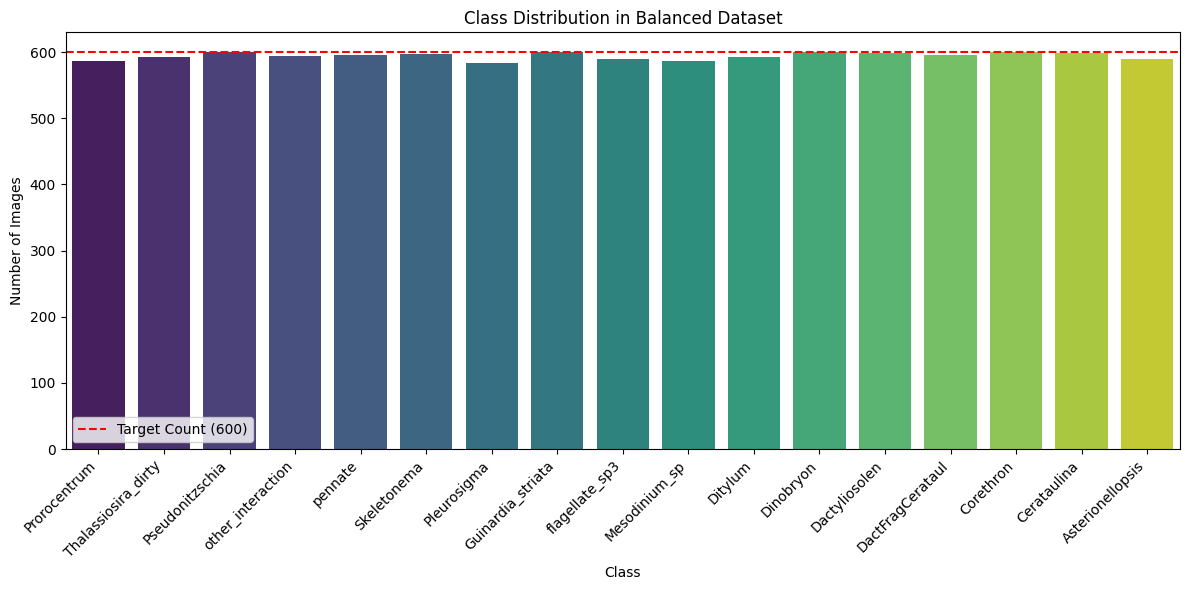

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Path to the balanced dataset
balanced_path = '/content/drive/MyDrive/ml project/aug/balanced'

# Get class counts
class_counts = {}
for class_name in os.listdir(balanced_path):
    class_path = os.path.join(balanced_path, class_name)
    if os.path.isdir(class_path):  # Ensure it's a directory
        class_counts[class_name] = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])

# Convert to DataFrame for visualization
df = pd.DataFrame.from_dict(class_counts, orient='index', columns=['count'])
df = df.reset_index().rename(columns={'index': 'class'})

# Print class counts for verification
print("Class Counts in Balanced Dataset:")
print(df.sort_values('class'))  # Sort by class name for consistency

# Create a count plot
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='class', y='count', palette='viridis')
plt.title('Class Distribution in Balanced Dataset')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=600, color='red', linestyle='--', label='Target Count (600)')
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

Here we are varifying the class count